## The Stock Market Data

In [11]:
## import packages

# Import NumPy for numerical array operations
import numpy as np
# Import pandas for data manipulation with DataFrames
import pandas as pd
# Import subplots from matplotlib for creating figures/axes
from matplotlib.pyplot import subplots
# Import statsmodels for fitting statistical models like GLM
import statsmodels.api as sm
# Import load_data to fetch built-in ISLP datasets
from ISLP import load_data
# Import ModelSpec (aliased MS) to build design matrices, and summarize to format model output
from ISLP.models import (ModelSpec as MS ,
summarize)
# Import confusion_table to build confusion matrices for classification results
from ISLP import confusion_table
# Import contrast to specify custom encodings (e.g., sum contrasts) for categorical variables
from ISLP.models import contrast
# Import LDA and QDA classifiers from scikit-learn's discriminant analysis module
from sklearn. discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
# Import Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
# Import K-Nearest Neighbors classifier
from sklearn.neighbors import KNeighborsClassifier
# Import StandardScaler to standardize features (zero mean, unit variance)
from sklearn.preprocessing import StandardScaler
# Import train_test_split to split data into training and test sets
from sklearn.model_selection import train_test_split
# Import LogisticRegression classifier
from sklearn.linear_model import LogisticRegression

In [17]:
## load the Smarket data
# Load the Smarket dataset (S&P 500 daily returns) from ISLP
Smarket = load_data('Smarket')
# Display the Smarket DataFrame
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


In [19]:
## Display variable names
# Show the column names of the Smarket DataFrame
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

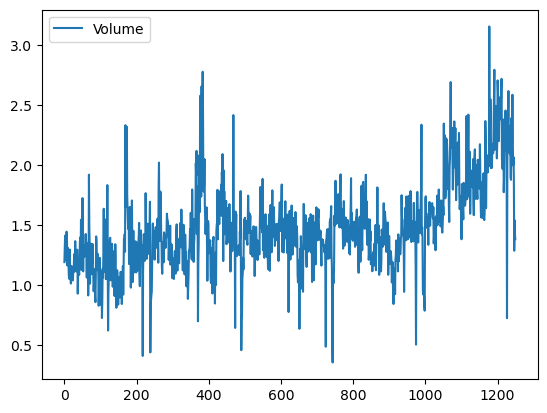

In [23]:
# Plot the daily trading Volume column over time
Smarket.plot(y='Volume');

## Logistic Regression

In [28]:
# Get all predictor column names, excluding the response and non-predictor columns
allvars = Smarket.columns.drop (['Today', 'Direction', 'Year'])
# Build a model specification (formula) using all selected predictors
design = MS(allvars)
# Create the design (predictor) matrix from the Smarket data
X = design.fit_transform(Smarket)
# Create the binary response: True if market direction is 'Up', else False
y = Smarket.Direction == 'Up'
# Fit a logistic regression model via GLM with a Binomial family
glm = sm.GLM(y,
X,
family=sm.families.Binomial ())
# Fit the model to the data
results = glm.fit()
# Display a formatted summary table of the fitted coefficients
summarize(results)

,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


In [30]:
# Show the estimated coefficients of the fitted model
results.params

intercept   -0.126000
Lag1        -0.073074
Lag2        -0.042301
Lag3         0.011085
Lag4         0.009359
Lag5         0.010313
Volume       0.135441
dtype: float64

In [32]:
# Show the p-values for each coefficient
results.pvalues

intercept    0.600700
Lag1         0.145232
Lag2         0.398352
Lag3         0.824334
Lag4         0.851445
Lag5         0.834998
Volume       0.392404
dtype: float64

In [34]:
# Compute predicted probabilities of the market going up for the training data
probs = results.predict ()
# Display the first 10 predicted probabilities
probs [:10]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778])

In [36]:
# Initialize all predicted labels as 'Down '
labels = np.array (['Down ']*1250)
# Reassign label to 'Up' wherever the predicted probability exceeds 0.5
labels[probs >0.5] = "Up"

In [38]:
# Build a confusion matrix comparing predicted labels to actual market direction
confusion_table(labels , Smarket.Direction)

Truth,Down,Down,Up
Predicted,,,
Down,0,0,0
Down,145,0,141
Up,457,0,507


In [40]:
# Compute training accuracy manually and via np.mean for comparison
(507+145) /1250 , np.mean(labels == Smarket.Direction)

(0.5216, 0.4056)

In [44]:
# Boolean mask selecting observations from before 2005 (training set)
train = (Smarket.Year < 2005)
# Subset the Smarket data to the training rows
Smarket_train = Smarket.loc[train]
# Subset the Smarket data to the test rows (2005 and later)
Smarket_test = Smarket.loc[~train]
# Check the shape of the test set
Smarket_test.shape

(252, 9)

In [48]:
# Split the design matrix into training and test portions
X_train , X_test = X.loc[train], X.loc[~train]
# Split the response variable into training and test portions
y_train , y_test = y.loc[train], y.loc[~train]
# Fit a logistic regression model using only the training data
glm_train = sm.GLM(y_train ,
X_train ,
family=sm.families.Binomial ())
# Fit the model
results = glm_train.fit()
# Predict probabilities on the held-out test data
probs = results.predict(exog=X_test)

In [50]:
# Extract the actual Direction labels
D = Smarket.Direction
# Split the actual labels into training and test sets
L_train , L_test = D.loc[train], D.loc[~train]

In [52]:
# Initialize all test predictions as 'Down '
labels = np.array (['Down ']*252)
# Reassign to 'Up' where the predicted probability exceeds 0.5
labels[probs >0.5] = 'Up'
# Build a confusion matrix on the test set
confusion_table(labels , L_test)

Truth,Down,Down,Up
Predicted,,,
Down,0,0,0
Down,77,0,97
Up,34,0,44


In [54]:
# Compute test accuracy and test error rate
np.mean(labels == L_test), np.mean(labels != L_test)

(0.1746031746031746, 0.8253968253968254)

In [60]:
# Build a simpler model using only Lag1 and Lag2 as predictors
model = MS(['Lag1', 'Lag2']).fit(Smarket)
# Transform the full data into the reduced design matrix
X = model.transform(Smarket)
# Split the reduced design matrix into training and test sets
X_train , X_test = X.loc[train], X.loc[~train]
# Refit the logistic regression model on the training data
glm_train = sm.GLM(y_train ,
X_train ,
family=sm.families.Binomial ())
# Fit the model
results = glm_train.fit()
# Predict probabilities on the test set
probs = results.predict(exog=X_test)
# Initialize predicted labels as 'Down'
labels = np.array (['Down']*252)
# Reassign to 'Up' where predicted probability exceeds 0.5
labels[probs >0.5] = 'Up'
# Build the confusion matrix for the reduced model
confusion_table(labels , L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [62]:
# Compute overall accuracy and precision for predicting 'Up' days
(35+106) /252 ,106/(106+76)

(0.5595238095238095, 0.5824175824175825)

In [64]:
# Create new hypothetical Lag1/Lag2 values to predict on
newdata = pd.DataFrame ({'Lag1':[1.2 , 1.5],
'Lag2':[1.1 , -0.8]});
# Transform the new data using the fitted model specification
newX = model.transform(newdata)
# Predict the probability of the market going up for the new data points
results.predict(newX)

0    0.479146
1    0.496094
dtype: float64

## Linear Discriminant Analysis

In [67]:
# Instantiate a Linear Discriminant Analysis classifier, storing covariance matrices
lda = LDA( store_covariance=True)

In [69]:
# Drop the intercept column since LDA/QDA do not require it
X_train , X_test = [M.drop(columns =['intercept'])
for M in [X_train , X_test ]]
# Fit the LDA model on the training data
lda.fit(X_train , L_train)

LinearDiscriminantAnalysis(store_covariance=True)

In [71]:
# Show the class-conditional feature means estimated by LDA
lda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [73]:
# Show the class labels known to the LDA model
lda.classes_

array(['Down', 'Up'], dtype='<U4')

In [75]:
# Show the estimated prior probabilities of each class
lda.priors_

array([0.49198397, 0.50801603])

In [77]:
# Show the linear discriminant scaling coefficients
lda.scalings_

array([[-0.64201904],
       [-0.51352928]])

In [79]:
# Predict class labels for the test set using LDA
lda_pred = lda.predict(X_test)

In [81]:
# Build a confusion matrix comparing LDA predictions to actual labels
confusion_table(lda_pred , L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [83]:
# Get predicted class probabilities from LDA
lda_prob = lda.predict_proba(X_test)
# Verify that thresholding probability at 0.5 matches the direct class predictions
np.all(
np.where(lda_prob [:,1] >= 0.5, 'Up','Down') == lda_pred
)

True

In [85]:
# Verify that taking the argmax of class probabilities matches the direct predictions
np.all(
[lda.classes_[i] for i in np.argmax(lda_prob , 1)] ==
lda_pred
)

True

In [87]:
# Count how many test observations have a predicted probability of 'Down' above 0.9
np.sum(lda_prob [:,0] > 0.9)

0

In [89]:
# Instantiate a Quadratic Discriminant Analysis classifier, storing covariance matrices
qda = QDA( store_covariance=True)
# Fit the QDA model on the training data
qda.fit(X_train , L_train)

QuadraticDiscriminantAnalysis(store_covariance=True)

In [91]:
# Show the class means and prior probabilities estimated by QDA
qda.means_ , qda.priors_

(array([[ 0.04279022,  0.03389409],
        [-0.03954635, -0.03132544]]),
 array([0.49198397, 0.50801603]))

In [93]:
# Show the estimated covariance matrix for the first class
qda.covariance_ [0]

array([[ 1.50662277, -0.03924806],
       [-0.03924806,  1.53559498]])

In [95]:
# Predict class labels for the test set using QDA
qda_pred = qda.predict(X_test)
# Build a confusion matrix for the QDA predictions
confusion_table(qda_pred , L_test)

Truth,Down,Up
Predicted,,
Down,30,20
Up,81,121


In [97]:
# Compute test accuracy for QDA
np.mean(qda_pred == L_test)

0.5992063492063492

## Naive Bayes

In [100]:
# Instantiate a Gaussian Naive Bayes classifier
NB = GaussianNB ()
# Fit the Naive Bayes model on the training data
NB.fit(X_train , L_train)

GaussianNB()

In [102]:
# Show the class labels known to the Naive Bayes model
NB.classes_

array(['Down', 'Up'], dtype='<U4')

In [104]:
# Show the estimated prior probability of each class
NB.class_prior_

array([0.49198397, 0.50801603])

In [106]:
# Show the estimated per-class, per-feature means
NB.theta_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [108]:
# Show the estimated per-class, per-feature variances
NB.var_

array([[1.50355429, 1.53246749],
       [1.51401364, 1.48732877]])

In [112]:
# Manually compute the feature means for the 'Down' class in the training data (for comparison)
X_train[L_train == 'Down']. mean ()

Lag1    0.042790
Lag2    0.033894
dtype: float64

In [116]:
# Manually compute the (population) feature variances for the 'Down' class
X_train[L_train == 'Down'].var(ddof =0)

Lag1    1.503554
Lag2    1.532467
dtype: float64

In [118]:
# Predict class labels on the test set using Naive Bayes
nb_labels = NB.predict(X_test)
# Build a confusion matrix for the Naive Bayes predictions
confusion_table(nb_labels , L_test)

Truth,Down,Up
Predicted,,
Down,29,20
Up,82,121


In [120]:
# Show predicted class probabilities for the first 5 test observations
NB.predict_proba(X_test)[:5]

array([[0.4873288 , 0.5126712 ],
       [0.47623584, 0.52376416],
       [0.46529531, 0.53470469],
       [0.47484469, 0.52515531],
       [0.49020587, 0.50979413]])

## K-Nearest Neighbors

In [125]:
# Instantiate a KNN classifier with K=1 neighbor
knn1 = KNeighborsClassifier(n_neighbors =1)
# Fit the KNN model on the training data
knn1.fit(X_train , L_train)
# Predict class labels on the test set
knn1_pred = knn1.predict(X_test)
# Build a confusion matrix for the K=1 KNN predictions
confusion_table(knn1_pred , L_test)

Truth,Down,Up
Predicted,,
Down,43,58
Up,68,83


In [127]:
# Compute accuracy manually and via np.mean for comparison
(83+43) /252, np.mean(knn1_pred == L_test)

(0.5, 0.5)

In [131]:
# Instantiate a KNN classifier with K=3 neighbors
knn3 = KNeighborsClassifier(n_neighbors =3)
# Fit on training data and predict on test data in one chained call
knn3_pred = knn3.fit(X_train , L_train).predict(X_test)
# Compute test accuracy for K=3
np.mean(knn3_pred == L_test)

0.5317460317460317

In [133]:
# Load the Caravan insurance dataset
Caravan = load_data('Caravan')
# Extract the Purchase response column (whether caravan insurance was purchased)
Purchase = Caravan.Purchase
# Show the counts of each class in the Purchase column
Purchase.value_counts ()

Purchase
No     5474
Yes     348
Name: count, dtype: int64

In [135]:
# Compute the proportion of customers who purchased insurance
348 / 5822

0.05977327378907592

In [137]:
# Create a feature DataFrame by dropping the response column
feature_df = Caravan.drop(columns =['Purchase'])

In [139]:
# Instantiate a StandardScaler to center and scale features
scaler = StandardScaler(with_mean=True ,
with_std=True ,
copy=True)

In [141]:
# Fit the scaler on the feature data (compute means and standard deviations)
scaler.fit(feature_df)
# Transform the features to have zero mean and unit variance
X_std = scaler.transform(feature_df)

In [143]:
# Wrap the standardized array back into a DataFrame with the original column names
feature_std = pd.DataFrame(
X_std ,
columns=feature_df.columns);
# Check that each standardized feature has standard deviation 1
feature_std.std()

MOSTYPE     1.000086
MAANTHUI    1.000086
MGEMOMV     1.000086
MGEMLEEF    1.000086
MOSHOOFD    1.000086
              ...   
AZEILPL     1.000086
APLEZIER    1.000086
AFIETS      1.000086
AINBOED     1.000086
ABYSTAND    1.000086
Length: 85, dtype: float64

In [145]:
# Split the standardized features and response into training and test sets
(X_train ,
X_test ,
y_train ,
y_test) = train_test_split(feature_std ,
Purchase ,
test_size =1000 ,
random_state =0)

In [147]:
# Instantiate a KNN classifier with K=1 neighbor
knn1 = KNeighborsClassifier (n_neighbors =1)
# Fit on training data and predict on the test data
knn1_pred = knn1.fit(X_train , y_train).predict(X_test)
# Compute the KNN test error rate and the error rate of always predicting 'No'
np.mean(y_test != knn1_pred), np.mean(y_test != "No")

(0.111, 0.067)

In [149]:
# Build a confusion matrix for the K=1 KNN predictions
confusion_table(knn1_pred , y_test)

Truth,No,Yes
Predicted,,
No,880,58
Yes,53,9


In [151]:
# Compute the precision (fraction of predicted purchasers who actually purchased)
9/(53+9)

0.14516129032258066

## Tuning Parameters

In [156]:
# Loop over K values from 1 to 5
for K in range(1, 6):
    # Instantiate a KNN classifier with the current K
    knn = KNeighborsClassifier(n_neighbors=K)
    # Fit on training data and predict on the test set
    knn_pred = knn.fit(X_train, y_train).predict(X_test)
    # Build the confusion matrix for this K
    C = confusion_table(knn_pred, y_test)

    # Define a message template to report results for this K
    templ = ('K={0:d}: # predicted to rent: {1:>2}, ' +
             '# who did rent {2:d}, accuracy {3:.1%}')

    # Total number of test observations predicted as 'Yes'
    pred = C.loc['Yes'].sum()
    # Number of those predicted 'Yes' that were correctly 'Yes'
    did_rent = C.loc['Yes', 'Yes']

    # Print the formatted results for this value of K
    print(templ.format(
        K,
        pred,
        did_rent,
        did_rent / pred
    ))

K=1: # predicted to rent: 62, # who did rent 9, accuracy 14.5%
K=2: # predicted to rent:  6, # who did rent 1, accuracy 16.7%
K=3: # predicted to rent: 20, # who did rent 3, accuracy 15.0%
K=4: # predicted to rent:  4, # who did rent 0, accuracy 0.0%
K=5: # predicted to rent:  7, # who did rent 1, accuracy 14.3%


## Comparison to Logistic Regression

In [161]:
# Instantiate a logistic regression model with very weak regularization (C=1e10)
logit = LogisticRegression (C=1e10 , solver='liblinear')
# Fit the logistic regression model on the training data
logit.fit(X_train , y_train)
# Predict class probabilities on the test data
logit_pred = logit.predict_proba(X_test)
# Assign 'Yes' if predicted probability of purchase exceeds threshold, else 'No'
logit_labels = np.where(logit_pred [:,1] > 5, 'Yes', 'No')
# Build a confusion matrix for the logistic regression predictions
confusion_table(logit_labels , y_test)

Truth,No,Yes
Predicted,,
No,933,67
Yes,0,0


In [163]:
# Reclassify using a lower probability threshold of 0.25 for predicting 'Yes'
logit_labels = np.where(logit_pred [: ,1] >0.25 , 'Yes', 'No')
# Build a confusion matrix using the new threshold
confusion_table(logit_labels , y_test)

Truth,No,Yes
Predicted,,
No,913,58
Yes,20,9


In [165]:
# Compute precision at the 0.25 threshold
9/(20+9)

0.3103448275862069

## Linear and Poisson Regression on the Bikeshare Data

In [168]:
# Load the Bikeshare dataset
Bike = load_data('Bikeshare')

In [170]:
# Check the shape and column names of the Bikeshare data
Bike.shape , Bike.columns

((8645, 15),
 Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
        'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
        'registered', 'bikers'],
       dtype='object'))

In [172]:
# Build a design matrix using month, hour, workingday, temp, and weather situation as predictors
X = MS(['mnth',
'hr',
'workingday',
'temp',
'weathersit']).fit_transform(Bike)
# Extract the response variable: number of bikers
Y = Bike['bikers']
# Fit an ordinary least squares regression model
M_lm = sm.OLS(Y, X).fit()
# Display a summary of the fitted coefficients
summarize(M_lm)

,coef,std err,t,P>|t|
intercept,-68.6317,5.307,-12.932,0.000
mnth[Feb],6.8452,4.287,1.597,0.110
mnth[March],16.5514,4.301,3.848,0.000
mnth[April],41.4249,4.972,8.331,0.000
mnth[May],72.5571,5.641,12.862,0.000
mnth[June],67.8187,6.544,10.364,0.000
mnth[July],45.3245,7.081,6.401,0.000
mnth[Aug],53.2430,6.640,8.019,0.000
mnth[Sept],66.6783,5.925,11.254,0.000
mnth[Oct],75.8343,4.950,15.319,0.000


In [194]:
# Define a sum-to-zero contrast encoding for the hour variable
hr_encode = contrast('hr', 'sum')
# Define a sum-to-zero contrast encoding for the month variable
mnth_encode = contrast('mnth', 'sum')

In [196]:
# Rebuild the design matrix using the sum-contrast encodings for month and hour
X2 = MS([mnth_encode ,
hr_encode ,
'workingday',
'temp',
         'weathersit']).fit_transform(Bike)
# Refit the OLS model using the new design matrix
M2_lm = sm.OLS(Y, X2).fit()
# Get a summary table of the new model's coefficients
S2 = summarize(M2_lm)
# Display the summary table
S2

,coef,std err,t,P>|t|
intercept,73.5974,5.132,14.340,0.000
mnth[Jan],-46.0871,4.085,-11.281,0.000
mnth[Feb],-39.2419,3.539,-11.088,0.000
mnth[March],-29.5357,3.155,-9.361,0.000
mnth[April],-4.6622,2.741,-1.701,0.089
mnth[May],26.4700,2.851,9.285,0.000
mnth[June],21.7317,3.465,6.272,0.000
mnth[July],-0.7626,3.908,-0.195,0.845
mnth[Aug],7.1560,3.535,2.024,0.043
mnth[Sept],20.5912,3.046,6.761,0.000


In [198]:
# Compute the sum of squared differences between the two models' fitted values
np.sum(( M_lm.fittedvalues - M2_lm.fittedvalues)**2)

1.0606239630734917e-20

In [200]:
# Check that the fitted values from both encodings are numerically equivalent
np.allclose(M_lm.fittedvalues , M2_lm.fittedvalues)

True

In [204]:
# Extract the coefficients corresponding to the month variable
coef_month = S2[S2.index.str.contains('mnth')]['coef']
# Display the month coefficients
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
Name: coef, dtype: float64

In [206]:
# Get the category labels for month
months = Bike['mnth']. dtype.categories
# Append the coefficient for December, computed as the negative sum of the others (sum-to-zero constraint)
coef_month = pd.concat ([
coef_month ,
pd.Series ([- coef_month.sum()],
index =['mnth[Dec]'
])
])
# Display the full set of month coefficients including December
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
mnth[Dec]       0.3705
dtype: float64

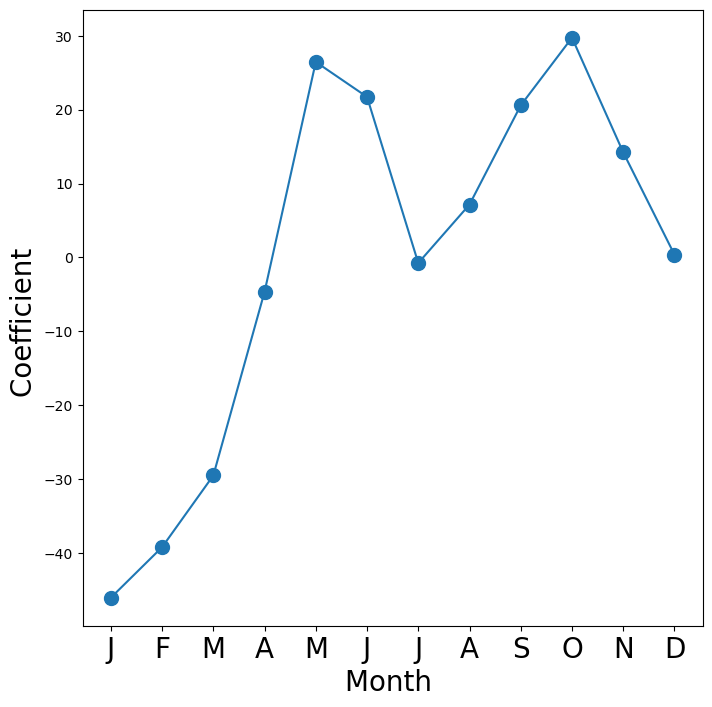

In [208]:
# Create a figure and axis for plotting the month coefficients
fig_month , ax_month = subplots(figsize =(8 ,8))
# Create x-axis positions for each month
x_month = np.arange(coef_month.shape [0])
# Plot the month coefficients as a line with circular markers
ax_month.plot(x_month , coef_month , marker='o', ms =10)
# Set the tick positions to match the months
ax_month.set_xticks(x_month)
# Label each tick with the month abbreviation
ax_month.set_xticklabels ([l[5] for l in coef_month.index], fontsize
=20)
# Label the x-axis
ax_month.set_xlabel('Month ', fontsize =20)
# Label the y-axis
ax_month.set_ylabel('Coefficient ', fontsize =20);

In [220]:
# Extract the coefficients corresponding to the hour variable
coef_hr = S2[S2.index.str.contains('hr')]['coef']
# Reorder the hour coefficients to match hours 0 through 22
coef_hr = coef_hr.reindex (['hr[{0}]'.format(h) for h in range (23) ])
# Append the coefficient for hour 23, computed via the sum-to-zero constraint
coef_hr = pd.concat ([ coef_hr ,pd.Series ([- coef_hr.sum()], index =['hr[23]'])
])

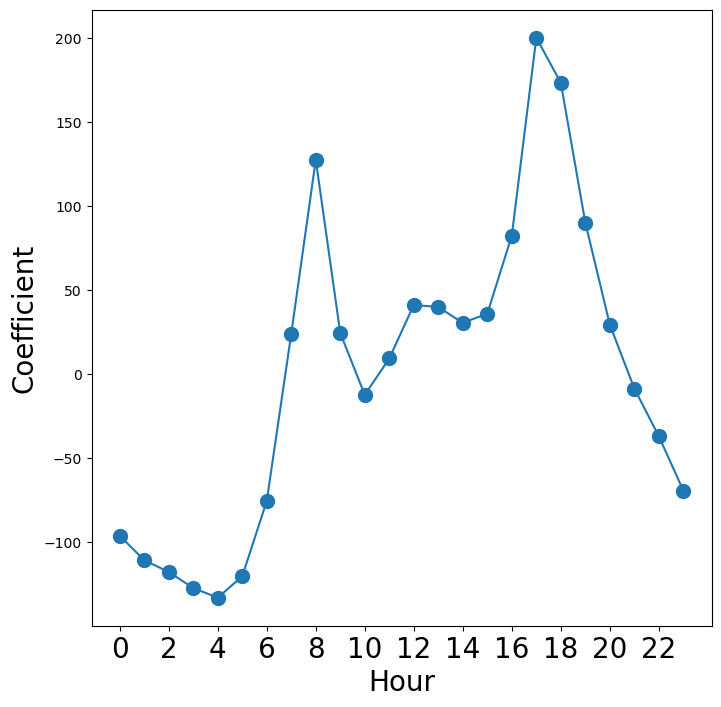

In [222]:
# Create a figure and axis for plotting the hourly coefficients
fig_hr , ax_hr = subplots(figsize =(8 ,8))
# Create x-axis positions for each hour
x_hr = np.arange(coef_hr.shape [0])
# Plot the hourly coefficients as a line with circular markers
ax_hr.plot(x_hr , coef_hr , marker='o', ms =10)
# Show tick marks at every second hour
ax_hr.set_xticks(x_hr [::2])
# Label the ticks with every second hour value
ax_hr.set_xticklabels (range (24) [::2] , fontsize =20)
# Label the x-axis
ax_hr.set_xlabel('Hour', fontsize =20)
# Label the y-axis
ax_hr.set_ylabel('Coefficient', fontsize =20);

In [224]:
# Fit a Poisson regression model (GLM with Poisson family) for count data
M_pois = sm.GLM(Y, X2 , family=sm.families.Poisson ()).fit()

In [226]:
# Get a summary table for the Poisson model
S_pois = summarize(M_pois)
# Extract the month coefficients from the Poisson model
coef_month = S_pois[S_pois.index.str.contains('mnth')]['coef']
# Append the December coefficient using the sum-to-zero constraint
coef_month = pd.concat ([ coef_month ,
pd.Series ([- coef_month.sum()],
index =['mnth[Dec]'])])
# Extract the hour coefficients from the Poisson model
coef_hr = S_pois[S_pois.index.str.contains('hr')]['coef']
# Append the hour-23 coefficient using the sum-to-zero constraint
coef_hr = pd.concat ([ coef_hr ,
pd.Series ([- coef_hr.sum()],
index =['hr[23]'])])

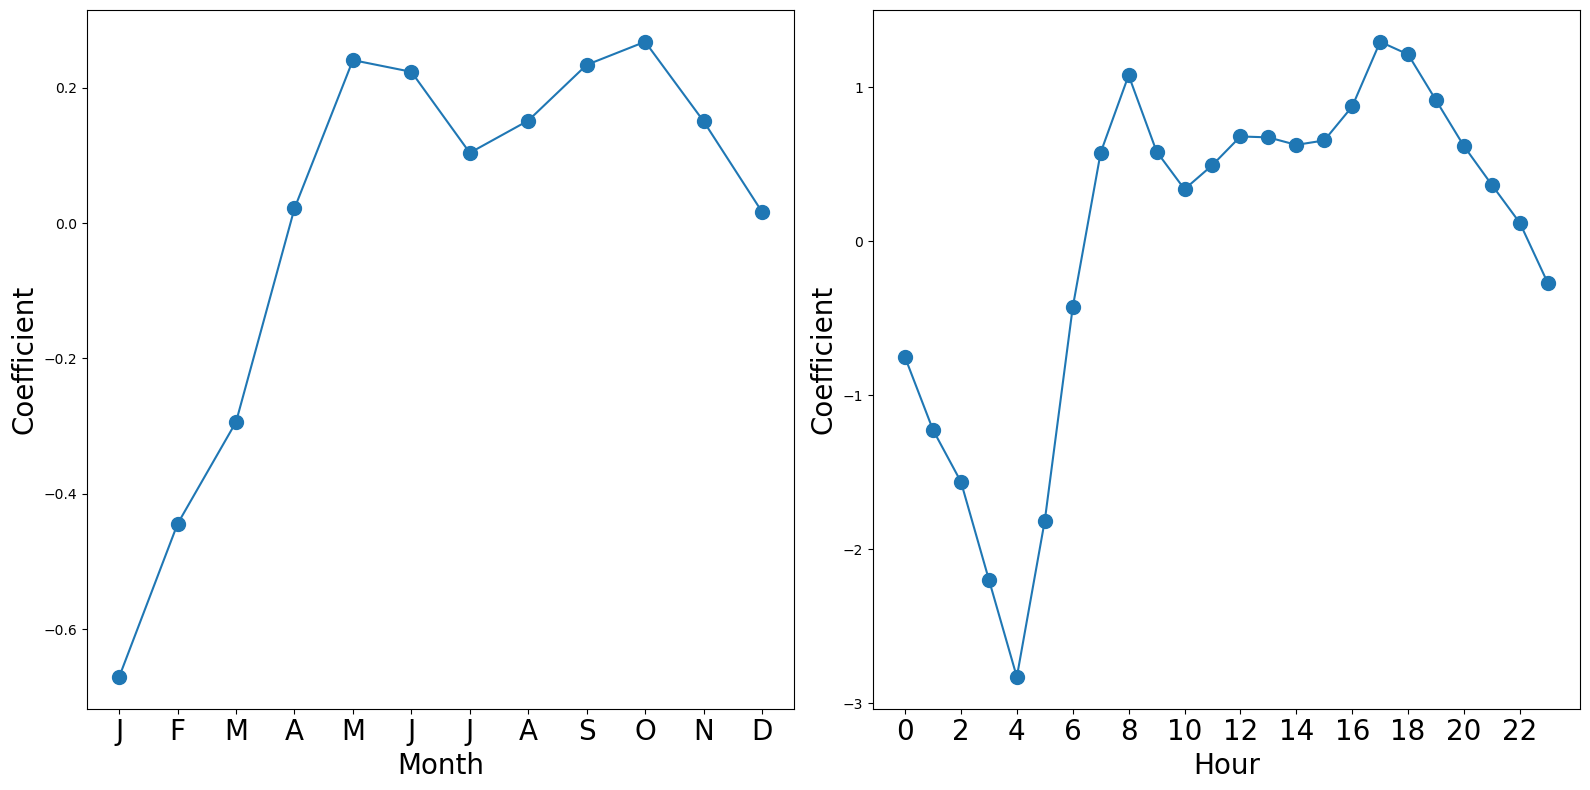

In [236]:
# Create a figure with two side-by-side subplots for month and hour effects
fig_pois, (ax_month, ax_hr) = subplots(1, 2, figsize=(16, 8))

# Month plot
# Plot the Poisson model's month coefficients
ax_month.plot(x_month, coef_month, marker='o', ms=10)
# Set tick positions for months
ax_month.set_xticks(x_month)
# Label ticks with month abbreviations
ax_month.set_xticklabels(
    [l[5] for l in coef_month.index],
    fontsize=20
)
# Label the x-axis
ax_month.set_xlabel('Month', fontsize=20)
# Label the y-axis
ax_month.set_ylabel('Coefficient', fontsize=20)

# Hour plot
# Plot the Poisson model's hour coefficients
ax_hr.plot(x_hr, coef_hr, marker='o', ms=10)
# Set tick positions at every second hour
ax_hr.set_xticks(range(0, 24, 2))
# Label ticks with hour values
ax_hr.set_xticklabels(range(0, 24, 2), fontsize=20)
# Label the x-axis
ax_hr.set_xlabel('Hour', fontsize=20)
# Label the y-axis
ax_hr.set_ylabel('Coefficient', fontsize=20)

# Adjust subplot spacing to avoid overlap
fig_pois.tight_layout()

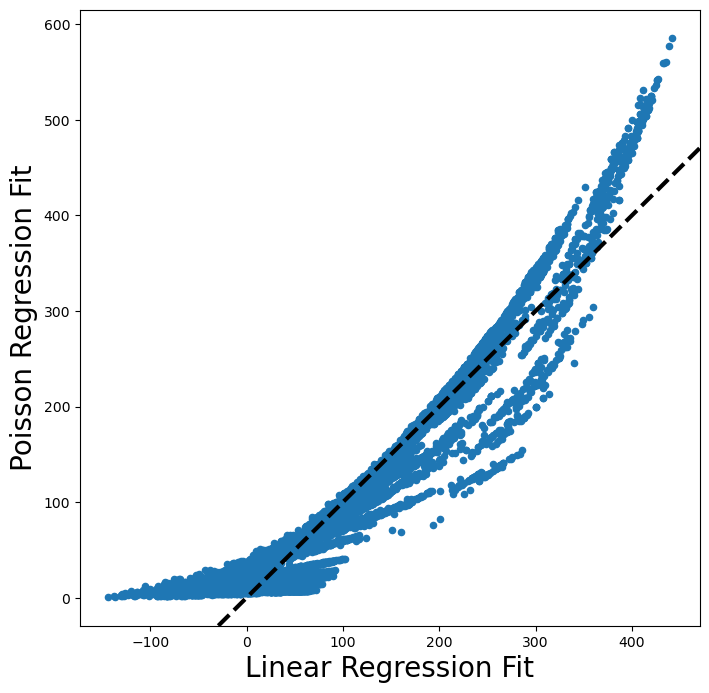

In [234]:
# Create a figure and axis to compare model fitted values
fig , ax = subplots(figsize =(8, 8))
# Scatter plot of linear regression fits vs. Poisson regression fits
ax.scatter(M2_lm.fittedvalues ,
M_pois.fittedvalues ,
s=20)
# Label the x-axis
ax.set_xlabel('Linear Regression Fit', fontsize =20)
# Label the y-axis
ax.set_ylabel('Poisson Regression Fit', fontsize =20)
# Draw a diagonal reference line (y = x) for comparison
ax.axline ([0,0], c='black', linewidth =3,
linestyle='--', slope =1);